In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18
import matplotlib.pyplot as plt
import numpy as np
import time

In [2]:
# 1. Setup Device
device = torch.device("cuda")
print(f"Training on: {torch.cuda.get_device_name(0)}")

def print_gpu_info():
    """Prints CUDA GPU information if available."""
    if not torch.cuda.is_available():
        print("CUDA is not available.")
        return

    gpu_id = torch.cuda.current_device()

    print(f"GPU : {torch.cuda.get_device_name(gpu_id)}")
    print(f"GPU capability: {torch.cuda.get_device_capability(gpu_id)}")

    gpu_props = torch.cuda.get_device_properties(gpu_id)

    print(f"GPU Memory : {gpu_props.total_memory / 1024**3:.2f} GB")
    print(f"Multiprocessors: {gpu_props.multi_processor_count}")
    print(f"Max Threads/MP : {gpu_props.max_threads_per_multi_processor}")
    
print_gpu_info()

Training on: NVIDIA GeForce RTX 3060
GPU : NVIDIA GeForce RTX 3060
GPU capability: (8, 6)
GPU Memory : 11.62 GB
Multiprocessors: 28
Max Threads/MP : 1536


In [3]:
# --- CONFIGURATION ---
BATCH_SIZE = 128    # Big batch to keep GPU busy
EPOCHS = 20          # Short run (increase for better accuracy)
LR = 0.001          # Learning Rate

In [4]:
# 2. Prepare Data (CIFAR-10)
print("📥 Downloading/Loading Data...")
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Normalize inputs
])

# Training Data
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE,
                                          shuffle=True, num_workers=2)

# Test Data (to check accuracy)
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

📥 Downloading/Loading Data...
Files already downloaded and verified
Files already downloaded and verified


In [5]:
# 3. Build the Model (ResNet-18)
# We modify the last layer because ResNet is usually built for 1000 classes, 
# but we only have 10.
model = resnet18(weights=None) # Start from scratch to force learning
model.fc = nn.Linear(model.fc.in_features, 10) # Change output to 10 classes
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

In [6]:
# 4. The Training Loop
print(f"\n🔥 Starting Training for {EPOCHS} Epochs...")
start_time = time.time()

for epoch in range(EPOCHS):
    running_loss = 0.0
    correct = 0
    total = 0
    
    model.train() # Set mode
    
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward + Backward + Optimize
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # End of Epoch Report
    epoch_acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {running_loss/len(trainloader):.4f} | Accuracy: {epoch_acc:.2f}%")

total_time = time.time() - start_time
print(f"✅ Training Complete in {total_time:.2f}s")


🔥 Starting Training for 20 Epochs...
Epoch 1/20 | Loss: 1.3658 | Accuracy: 51.12%
Epoch 2/20 | Loss: 0.9743 | Accuracy: 65.64%
Epoch 3/20 | Loss: 0.7965 | Accuracy: 71.92%
Epoch 4/20 | Loss: 0.6773 | Accuracy: 76.47%
Epoch 5/20 | Loss: 0.5657 | Accuracy: 80.33%
Epoch 6/20 | Loss: 0.4790 | Accuracy: 83.32%
Epoch 7/20 | Loss: 0.3891 | Accuracy: 86.34%
Epoch 8/20 | Loss: 0.3184 | Accuracy: 88.77%
Epoch 9/20 | Loss: 0.2565 | Accuracy: 90.80%
Epoch 10/20 | Loss: 0.2092 | Accuracy: 92.45%
Epoch 11/20 | Loss: 0.1772 | Accuracy: 93.63%
Epoch 12/20 | Loss: 0.1473 | Accuracy: 94.81%
Epoch 13/20 | Loss: 0.1250 | Accuracy: 95.64%
Epoch 14/20 | Loss: 0.1047 | Accuracy: 96.29%
Epoch 15/20 | Loss: 0.0995 | Accuracy: 96.48%
Epoch 16/20 | Loss: 0.0961 | Accuracy: 96.62%
Epoch 17/20 | Loss: 0.0820 | Accuracy: 97.14%
Epoch 18/20 | Loss: 0.0757 | Accuracy: 97.49%
Epoch 19/20 | Loss: 0.0766 | Accuracy: 97.29%
Epoch 20/20 | Loss: 0.0709 | Accuracy: 97.56%
✅ Training Complete in 100.83s



🧐 Validating on a batch of test images...
Visualizing 16 random test images:


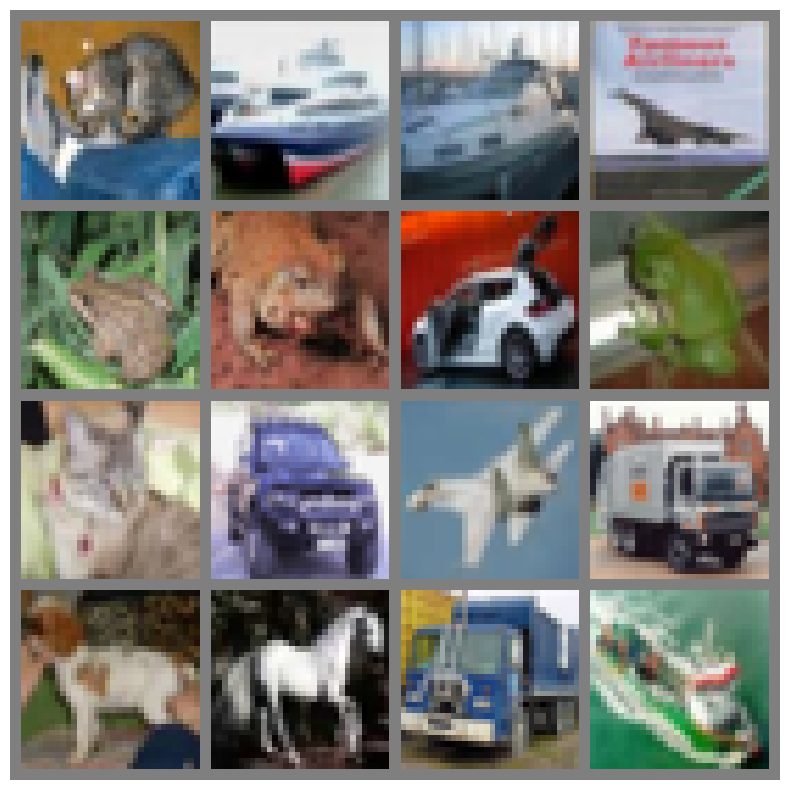

                    --- GROUND TRUTH ---                     |                      --- PREDICTION ---                     
cat        ship       ship       plane                       | cat        ship       plane      plane                      
frog       frog       car        frog                        | bird       deer       car        frog                       
cat        car        plane      truck                       | cat        car        plane      truck                      
dog        horse      truck      ship                        | dog        horse      truck      ship                       

Batch Accuracy: 81.2%


In [7]:
# --- REPLACEMENT FOR STEP 5: VISUAL VALIDATION ---

def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.figure(figsize=(10, 10)) # Make the figure bigger
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

print("\n🧐 Validating on a batch of test images...")

# Get a batch of test images
dataiter = iter(testloader)
images, labels = next(dataiter)

# We want to show exactly 16 images (4x4 Grid)
num_images = 16
images = images[:num_images]
labels = labels[:num_images]

# Move to GPU for prediction
images_gpu = images.to(device)
outputs = model(images_gpu)
_, predicted = torch.max(outputs, 1)

# Plot the images
print("Visualizing 16 random test images:")
imshow(torchvision.utils.make_grid(images, nrow=4, padding=2))

# Print the labels in a grid format to match the image
print(f"{'--- GROUND TRUTH ---':^60} | {'--- PREDICTION ---':^60}")
for i in range(0, num_images, 4):
    # Slice the next 4 items
    truth_row = labels[i:i+4]
    pred_row = predicted[i:i+4]
    
    # Format the rows
    truth_str = '   '.join(f'{classes[x]:<8}' for x in truth_row)
    pred_str = '   '.join(f'{classes[x]:<8}' for x in pred_row)
    
    # Check for mismatches (Color the text red if possible, or just mark it)
    # Here we just print them side by side
    print(f"{truth_str:<60} | {pred_str:<60}")

# Calculate batch accuracy
batch_acc = (predicted == labels.to(device)).sum().item() / num_images * 100
print(f"\nBatch Accuracy: {batch_acc:.1f}%")